# 1. Informasjon om filen

# 2. Innlasting av data

In [916]:
import sys
!{sys.executable} -m pip install scikit-learn

In [917]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [918]:
df_full = pd.read_csv("compas-scores-two-years.csv")
df_full = df_full[df_full["days_b_screening_arrest"] <= 30]
df_full = df_full[df_full["days_b_screening_arrest"] >= -30]

df_full.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1


In [919]:
df_full.info()

<class 'pandas.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       6172 non-null   int64  
 1   name                     6172 non-null   str    
 2   first                    6172 non-null   str    
 3   last                     6172 non-null   str    
 4   compas_screening_date    6172 non-null   str    
 5   sex                      6172 non-null   str    
 6   dob                      6172 non-null   str    
 7   age                      6172 non-null   int64  
 8   age_cat                  6172 non-null   str    
 9   race                     6172 non-null   str    
 10  juv_fel_count            6172 non-null   int64  
 11  decile_score             6172 non-null   int64  
 12  juv_misd_count           6172 non-null   int64  
 13  juv_other_count          6172 non-null   int64  
 14  priors_count             6172 non-null  

In [920]:
df_full['compas_screening_date'] = pd.to_datetime(df_full['compas_screening_date'])

earliest_date = df_full['compas_screening_date'].min()
latest_date = df_full['compas_screening_date'].max()

print("Earliest date:", earliest_date)
print("Latest date:", latest_date)

Earliest date: 2013-01-01 00:00:00
Latest date: 2014-12-31 00:00:00


In [921]:
print(df_full.columns)

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='str')


In [922]:
print(df_full["race"].unique())

<StringArray>
[           'Other', 'African-American',        'Caucasian',
         'Hispanic',            'Asian',  'Native American']
Length: 6, dtype: str


In [923]:
print(df_full["c_charge_degree"].unique())

<StringArray>
['F', 'M']
Length: 2, dtype: str


Kolonner som ikke er nyttige: id, name, first, last, 
Kolonner som sannsynligvis ikke er nyttige: dob
Viktige kolonner: sex, age, age_cat, race

Ikke sett på alt...

# 3. Enkle analyser

### Hvor ofte ulike grupper gjentar forbrytelser

##### Kjønn

<Axes: xlabel='sex'>

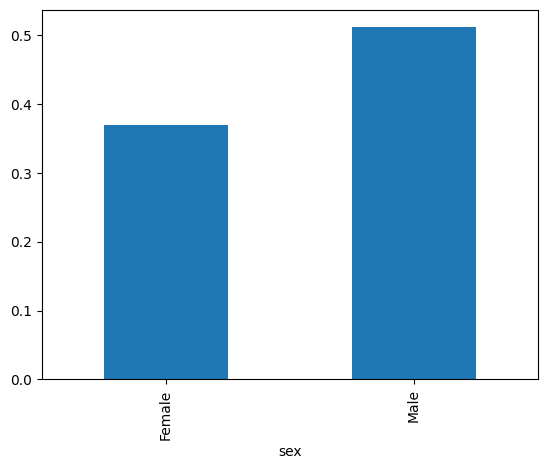

In [924]:

average_recidivism = df_full.groupby('sex')['is_recid'].mean()
average_recidivism.plot.bar()

##### Etnisitet

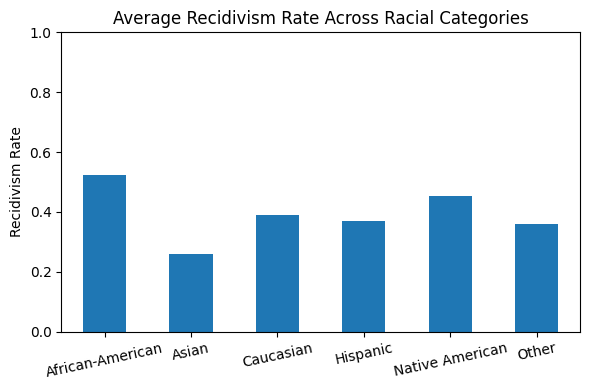

race
African-American    0.523150
Asian               0.258065
Caucasian           0.390870
Hispanic            0.371316
Native American     0.454545
Other               0.361516
Name: two_year_recid, dtype: float64


In [925]:
average_recidivism = df_full.groupby('race')['two_year_recid'].mean()

ax = average_recidivism.plot(kind="bar", figsize=(6, 4))

ax.set_xlabel("")      
ax.set_ylabel("Recidivism Rate")          
ax.set_title("Average Recidivism Rate Across Racial Categories")  

# Y-axis limits
ax.set_ylim(0, 1)



# Optional: rotate x labels if needed
plt.xticks(rotation=12)

plt.tight_layout()
plt.show()
print(average_recidivism)

### Hvor ofte algoritmen predikerer tilbakefall (score 1-10 av risiko lav-høy)

##### Kjønn

<Axes: xlabel='sex'>

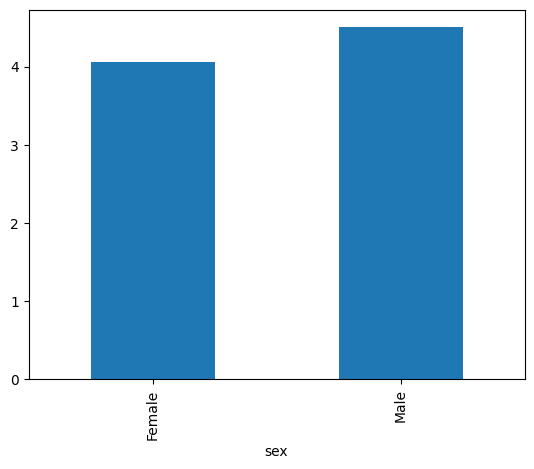

In [926]:
average_recidivism = df_full.groupby('sex')['decile_score'].mean()
average_recidivism.plot.bar()

##### Etnisitet

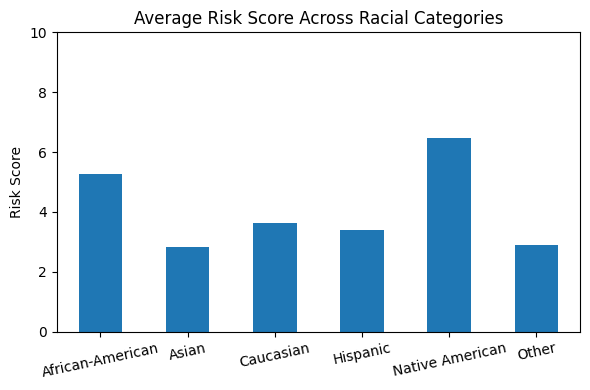

race
African-American    5.276850
Asian               2.838710
Caucasian           3.635283
Hispanic            3.383104
Native American     6.454545
Other               2.889213
Name: decile_score, dtype: float64


In [927]:
average_recidivism = df_full.groupby('race')['decile_score'].mean()

ax = average_recidivism.plot(kind="bar", figsize=(6, 4))

ax.set_xlabel("")      
ax.set_ylabel("Risk Score")          
ax.set_title('Average Risk Score Across Racial Categories')  

# Y-axis limits
ax.set_ylim(0, 10)



# Optional: rotate x labels if needed
plt.xticks(rotation=12)

plt.tight_layout()
plt.show()
print(average_recidivism)

### Relativ frekvens av risikovurdering

##### Kjønn

<Axes: xlabel='sex,v_score_text'>

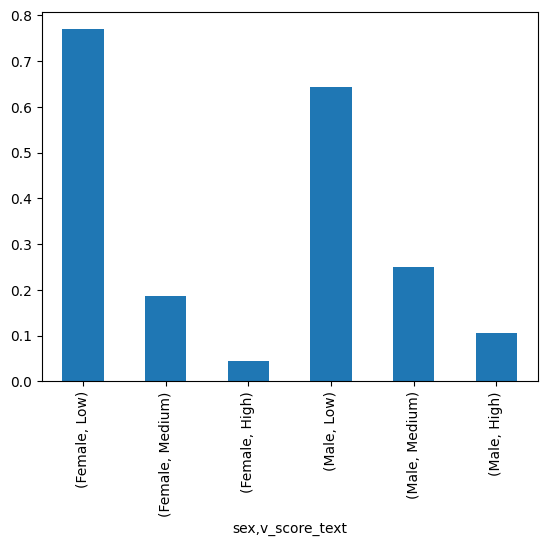

In [928]:
rel_freq = df_full.groupby('sex')['v_score_text'].value_counts(normalize=True)
rel_freq.plot.bar()

Etnisitet

<Axes: xlabel='race,v_score_text'>

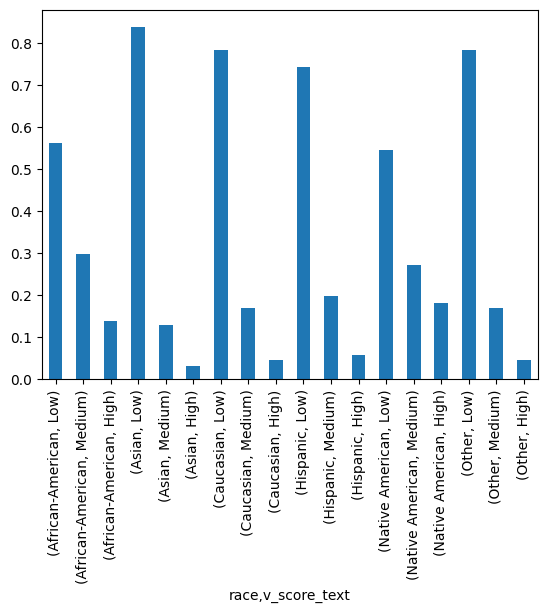

In [929]:
rel_freq = df_full.groupby('race')['v_score_text'].value_counts(normalize=True)
rel_freq.plot.bar()

### Risikoskårer for ulike grupper

hvor ofte de som begikk nye straffbare hadlinger (og de som ikke gjorde det) fikk ulike risikoskårer, og hvordan dette ser ut hvis du kun ser på hvite eller svarte.

##### Totalt

<Axes: xlabel='is_recid,v_score_text'>

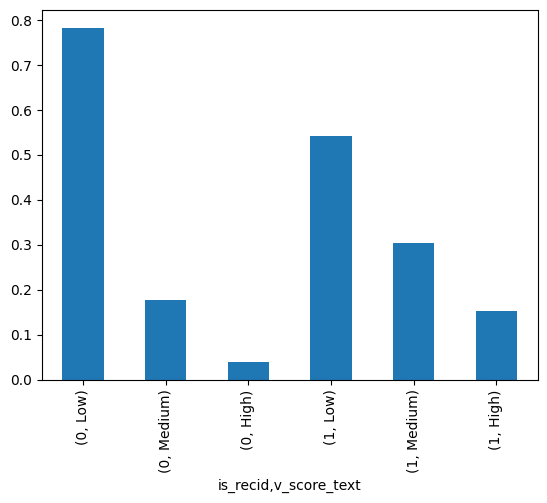

In [930]:
rel_freq = df_full.groupby('is_recid')['v_score_text'].value_counts(normalize=True)
rel_freq.plot.bar()

##### Internt etnisitet

<Axes: xlabel='is_recid,v_score_text'>

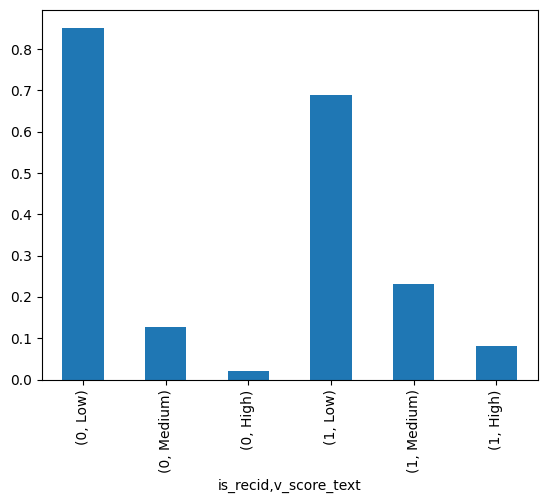

In [931]:
white = df_full[df_full['race'] == 'Caucasian']

rel_freq = white.groupby('is_recid')['v_score_text'].value_counts(normalize=True)
rel_freq.plot.bar()


<Axes: xlabel='is_recid,v_score_text'>

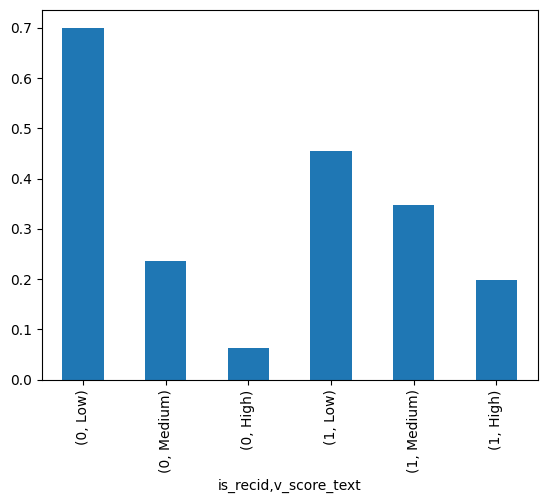

In [932]:
black = df_full[df_full['race'] == 'African-American']

rel_freq = black.groupby('is_recid')['v_score_text'].value_counts(normalize=True)
rel_freq.plot.bar()

### Confusion matrix // Treffsikkerhet positive og negative

Algoritmedataen sier ikke eksplisitt om den mener noen vil ha tilbakefall eller ikke. Det er tydeligvis vanlig å gruppere 1-4 / low som nei, og 5-10 / medium eller high som ja.

In [933]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

##### Totalt over alle grupper

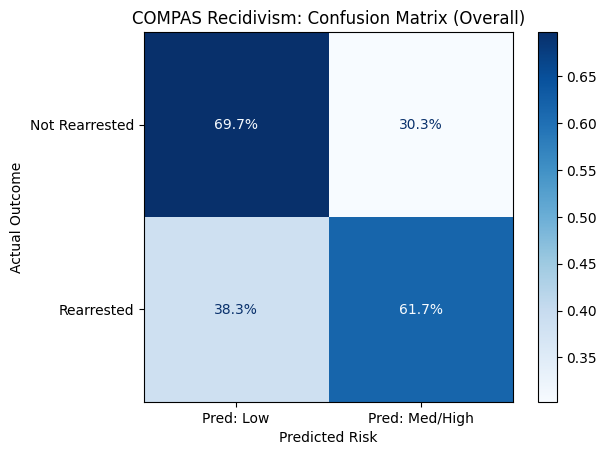

P(Recid | medium eller high): 63.0%


In [934]:
df_full['predicted_recid'] = df_full['score_text'].apply(lambda x: 1 if x in ['Medium', 'High'] else 0)
cm_rates = confusion_matrix(df_full['two_year_recid'], df_full['predicted_recid'], normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rates, 
                              display_labels=['Low Risk (0)', 'Med/High Risk (1)'])

disp.plot(cmap='Blues', values_format='.1%')

# Customize axis labels
disp.ax_.set_xlabel("Predicted Risk")
disp.ax_.set_ylabel("Actual Outcome")

# Customize tick labels separately
disp.ax_.set_xticklabels(['Pred: Low', 'Pred: Med/High'])
disp.ax_.set_yticklabels(['Not Rearrested', 'Rearrested'])

plt.title('COMPAS Recidivism: Confusion Matrix (Overall)')
plt.show()

rated_dangerous = df_full[df_full['predicted_recid'] == 1]
p_recid = rated_dangerous['two_year_recid'].mean()
print(f"P(Recid | medium eller high): {p_recid:.1%}")

##### Filtrert etter grupper

##### Hvite

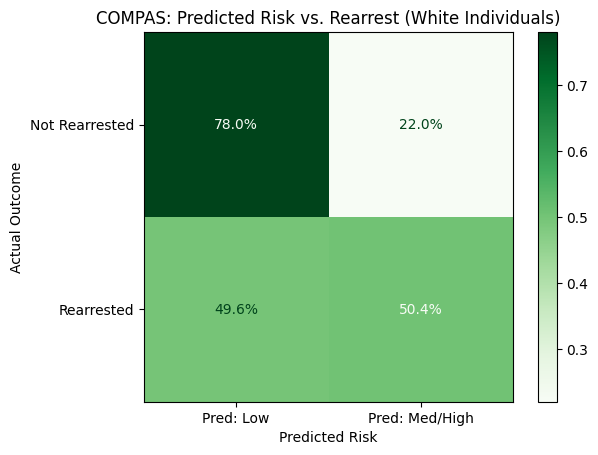

P(Recid | medium eller high): 59.5%


In [935]:
sortby = 'Caucasian'

df_full['predicted_recid'] = df_full['score_text'].apply(lambda x: 1 if x in ['Medium', 'High'] else 0)
df_sorted = df_full[df_full['race'] == sortby]


cm_rates = confusion_matrix(df_sorted['two_year_recid'], df_sorted['predicted_recid'], normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rates, 
                              display_labels=['Low Risk (0)', 'Med/High Risk (1)'])

disp.plot(cmap='Greens', values_format='.1%')

# Customize axis labels
disp.ax_.set_xlabel("Predicted Risk")
disp.ax_.set_ylabel("Actual Outcome")

# Customize tick labels separately
disp.ax_.set_xticklabels(['Pred: Low', 'Pred: Med/High'])
disp.ax_.set_yticklabels(['Not Rearrested', 'Rearrested'])

plt.title('COMPAS: Predicted Risk vs. Rearrest (White Individuals)')
plt.show()

rated_dangerous = df_sorted[df_sorted['predicted_recid'] == 1]
p_recid = rated_dangerous['two_year_recid'].mean()
print(f"P(Recid | medium eller high): {p_recid:.1%}")

##### Svarte

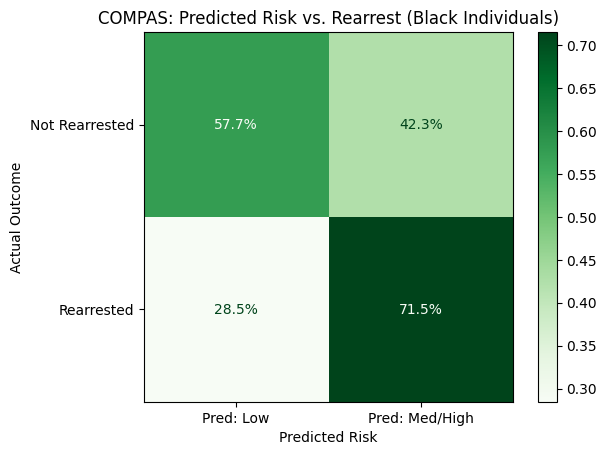

P(Recid | medium eller high): 65.0%


In [936]:
sortby = 'African-American'

df_full['predicted_recid'] = df_full['score_text'].apply(lambda x: 1 if x in ['Medium', 'High'] else 0)
df_sorted = df_full[df_full['race'] == sortby]


cm_rates = confusion_matrix(df_sorted['two_year_recid'], df_sorted['predicted_recid'], normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rates, 
                              display_labels=['Low Risk (0)', 'Med/High Risk (1)'])

disp.plot(cmap='Greens', values_format='.1%')

# Customize axis labels
disp.ax_.set_xlabel("Predicted Risk")
disp.ax_.set_ylabel("Actual Outcome")

# Customize tick labels separately
disp.ax_.set_xticklabels(['Pred: Low', 'Pred: Med/High'])
disp.ax_.set_yticklabels(['Not Rearrested', 'Rearrested'])

plt.title('COMPAS: Predicted Risk vs. Rearrest (Black Individuals)')
plt.show()

rated_dangerous = df_sorted[df_sorted['predicted_recid'] == 1]
p_recid = rated_dangerous['two_year_recid'].mean()
print(f"P(Recid | medium eller high): {p_recid:.1%}")

##### Menn

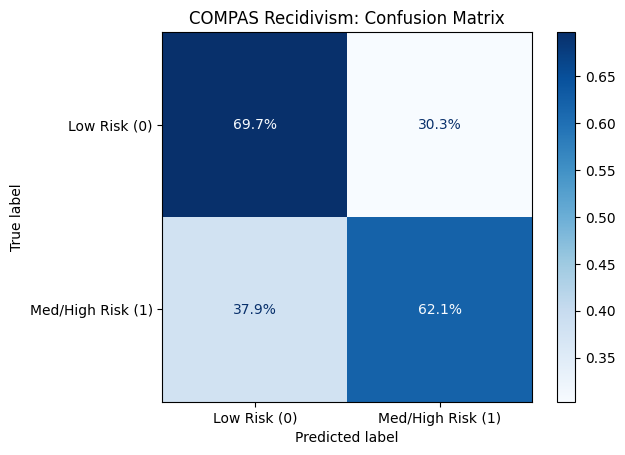

P(Recid | medium eller high): 65.4%


In [937]:
sortby = 'Male'

df_full['predicted_recid'] = df_full['score_text'].apply(lambda x: 1 if x in ['Medium', 'High'] else 0)
df_sorted = df_full[df_full['sex'] == sortby]


cm_rates = confusion_matrix(df_sorted['two_year_recid'], df_sorted['predicted_recid'], normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rates, 
                              display_labels=['Low Risk (0)', 'Med/High Risk (1)'])

disp.plot(cmap='Blues', values_format='.1%')

plt.title('COMPAS Recidivism: Confusion Matrix')
plt.show()

rated_dangerous = df_sorted[df_sorted['predicted_recid'] == 1]
p_recid = rated_dangerous['two_year_recid'].mean()
print(f"P(Recid | medium eller high): {p_recid:.1%}")

##### Kvinner

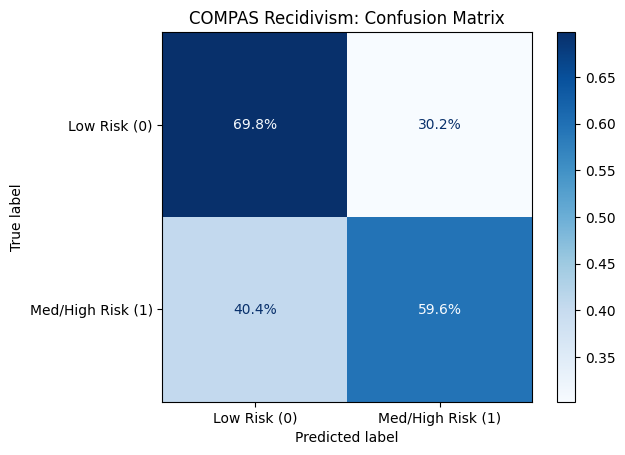

P(Recid | medium eller high): 51.7%


In [938]:
sortby = 'Female'

df_full['predicted_recid'] = df_full['score_text'].apply(lambda x: 1 if x in ['Medium', 'High'] else 0)
df_sorted = df_full[df_full['sex'] == sortby]


cm_rates = confusion_matrix(df_sorted['two_year_recid'], df_sorted['predicted_recid'], normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rates, 
                              display_labels=['Low Risk (0)', 'Med/High Risk (1)'])

disp.plot(cmap='Blues', values_format='.1%')

plt.title('COMPAS Recidivism: Confusion Matrix')
plt.show()

rated_dangerous = df_sorted[df_sorted['predicted_recid'] == 1]
p_recid = rated_dangerous['two_year_recid'].mean()
print(f"P(Recid | medium eller high): {p_recid:.1%}")

### Bayes setning og diskriminering

Bayes' setning

$$P(A|B) = \frac{P(B|A)P(A)}{P(B)}$$

kan gi en slags forklaring på sammenhengen mellom diskriminering og presisjon. La hendelsene våre være R (recidivism) og D (dangerous). Vi får denne formelen:

$$P(R|D) = \frac{P(D|R)P(R)}{P(D)}$$

For at modellen skal regnes som "rettferdig", kan det være rimelig å si at P(R|D) skal være lik for alle grupper. Det vil altså si at av de som modellen regner som farlige, så skal like mange begå nye forbrytelser.

I datasettet vet man at det er skjevheter. I vårt datasett er for eksempel P(R) høyere for svarte enn hvite. Historisk har en større andel svarte begått nye lovbrudd. For at likningen skal holde, så må modellen tilpasse blandt den svarte befolkningen. Enten må P(D) også øke, altså må modellen flagge flere svarte mennesker, eller så må P(D|R) senkes. Å flagge flere svarte kan virke urettferdig. Å senke P(D|R), altså andelen av de som begår nye lovbrudd, som faktisk blir regnet som farlige, er en stor belastning på hvor god modellen er. 

### Reprodusering av ProPublica; isolering av andre faktorer

In [939]:
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import PartialDependenceDisplay

In [940]:
X = df_full[["age_cat", "race", "sex", "priors_count", "c_charge_degree", "two_year_recid"]]
categorical_cols = ["age_cat", "race", "sex", "c_charge_degree"]
X = pd.get_dummies(X, columns=categorical_cols, prefix=categorical_cols, prefix_sep='_')
X = X.drop(["age_cat_25 - 45", "race_Caucasian", "sex_Male", "c_charge_degree_F"], axis=1)
Y = df_full["score_text"] != "Low"

model = LogisticRegression()
model.fit(X, Y)


b = model.intercept_[0]
coefs = dict(zip(X.columns, model.coef_[0]))



In [941]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

control = sigmoid( b )
weight_african_american = coefs["race_African-American"]

racialBias = np.exp(weight_african_american) / (1 - control + (control * np.exp(weight_african_american)))



In [942]:
print(f"Bias (b): {b:.4f}")
print(f"Weight for African-American: {weight_african_american:.4f}")
print(f"Control (Baseline Probability): {control:.1%}")
print(f"Racial Bias Multiplier: {racialBias:.2f}")

Bias (b): -1.5236
Weight for African-American: 0.4782
Control (Baseline Probability): 17.9%
Racial Bias Multiplier: 1.45


c:\Users\harei\Documents\4_semester\HON2200\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


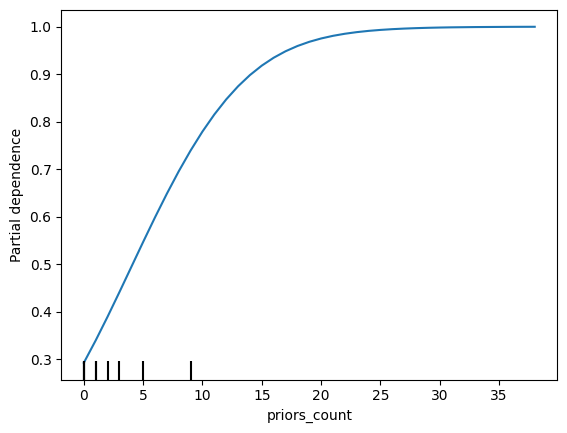

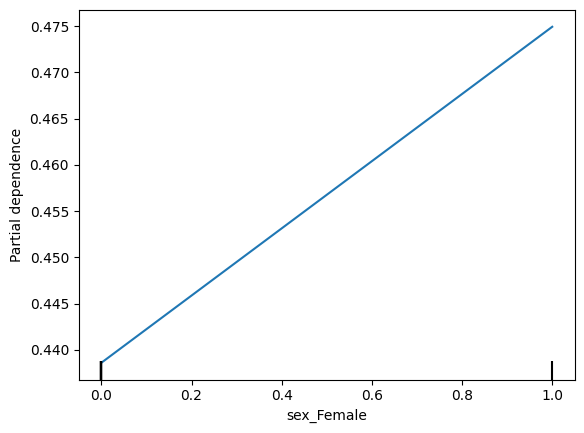

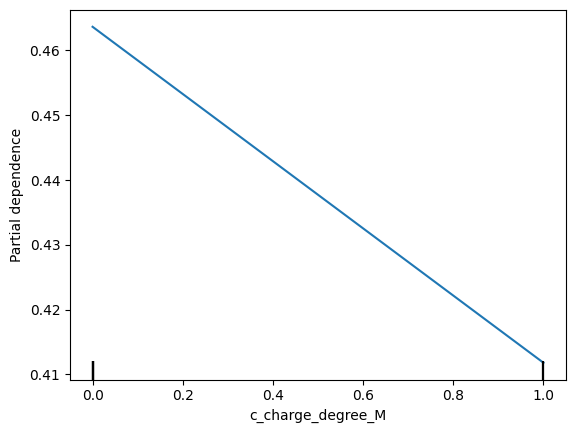

In [943]:
for feature in ['priors_count', 'sex_Female', 'c_charge_degree_M']:
    PartialDependenceDisplay.from_estimator(model, X, features=[feature])

### Random forest modell

In [944]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [945]:
X = df_full[["age", "sex", "race", "priors_count", "c_charge_degree", "two_year_recid"]]
categorical_cols = ["sex", "c_charge_degree", "race"]
X = pd.get_dummies(X, columns=categorical_cols, prefix=categorical_cols, prefix_sep='_')
X = X.drop(["sex_Male", "c_charge_degree_F", "race_Caucasian"], axis=1)
allowed_columns = [
    "age",
    "priors_count", 
    "sex_Female", 
    "c_charge_degree_M"]
Y = df_full["two_year_recid"]

X_train_all, X_test_all, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

X_train = X_train_all[allowed_columns]
X_test = X_test_all[allowed_columns]

skog = RandomForestClassifier(n_estimators=100, max_features="sqrt", random_state=42)
skog.fit(X_train, Y_train)
print(f"Ferdigtrent skog med {skog.n_estimators} trær, max_features={skog.max_features}")

Ferdigtrent skog med 100 trær, max_features=sqrt


In [946]:
print(X.columns)

Index(['age', 'priors_count', 'two_year_recid', 'sex_Female',
       'c_charge_degree_M', 'race_African-American', 'race_Asian',
       'race_Hispanic', 'race_Native American', 'race_Other'],
      dtype='str')


In [947]:
Y_pred = skog.predict(X_test)
score = accuracy_score(Y_test, Y_pred)
print(f'Random forest score på test-data: {score}')

Random forest score på test-data: 0.6461538461538462


##### Prediksjoner på all data

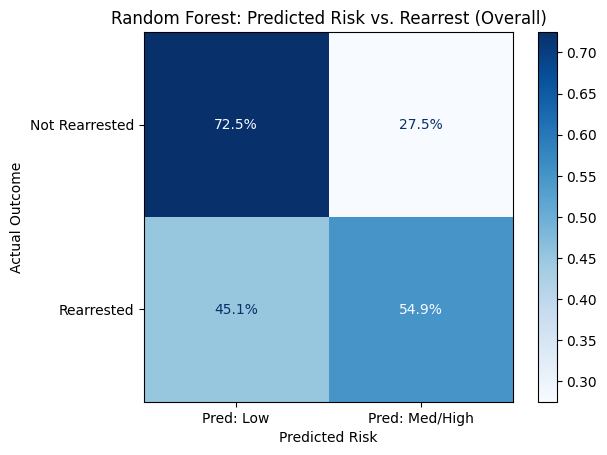

PPV (Precision): 0.6171


In [948]:

cm_rates = confusion_matrix(Y_test, Y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rates, 
                              display_labels=['Low Risk (0)', 'Med/High Risk (1)'])

disp.plot(cmap='Blues', values_format='.1%')


# Customize axis labels
disp.ax_.set_xlabel("Predicted Risk")
disp.ax_.set_ylabel("Actual Outcome")

# Customize tick labels separately
disp.ax_.set_xticklabels(['Pred: Low', 'Pred: Med/High'])
disp.ax_.set_yticklabels(['Not Rearrested', 'Rearrested'])

plt.title('Random Forest: Predicted Risk vs. Rearrest (Overall)')
plt.show()

y_true = np.array(Y_test)
y_pred = np.array(Y_pred)

y_true_pos = (y_true == 1)
y_pred_pos = (y_pred == 1)

TP = np.sum(y_pred_pos & y_true_pos)
FP = np.sum(y_pred_pos & ~y_true_pos)
ppv = TP / (TP + FP) if (TP + FP) > 0 else 0.0

print(f"PPV (Precision): {ppv:.4f}")

##### Prediksjoner på kun hvite

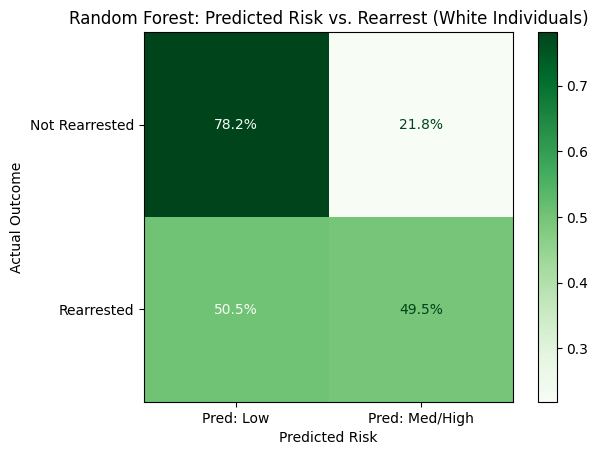

PPV (Precision): 0.6059


In [949]:
#Kun hvite

X_test_white_with_illegal = X_test_all[
    (X_test_all['race_African-American'] == 0) & 
    (X_test_all['race_Asian'] == 0) & 
    (X_test_all['race_Hispanic'] == 0) & 
    (X_test_all['race_Native American'] == 0)
]

X_test_white = X_test_white_with_illegal[allowed_columns]
Y_pred_white = skog.predict(X_test_white)

Y_test_white = X_test_white_with_illegal["two_year_recid"]

cm_rates = confusion_matrix(Y_test_white, Y_pred_white, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rates, 
                              display_labels=['Low Risk (0)', 'Med/High Risk (1)'])

disp.plot(cmap='Greens', values_format='.1%')


# Customize axis labels
disp.ax_.set_xlabel("Predicted Risk")
disp.ax_.set_ylabel("Actual Outcome")

# Customize tick labels separately
disp.ax_.set_xticklabels(['Pred: Low', 'Pred: Med/High'])
disp.ax_.set_yticklabels(['Not Rearrested', 'Rearrested'])

plt.title('Random Forest: Predicted Risk vs. Rearrest (White Individuals)')
plt.show()

y_true = np.array(Y_test_white)
y_pred = np.array(Y_pred_white)

y_true_pos = (y_true == 1)
y_pred_pos = (y_pred == 1)

TP = np.sum(y_pred_pos & y_true_pos)
FP = np.sum(y_pred_pos & ~y_true_pos)
ppv = TP / (TP + FP) if (TP + FP) > 0 else 0.0

print(f"PPV (Precision): {ppv:.4f}")

##### Kun svarte

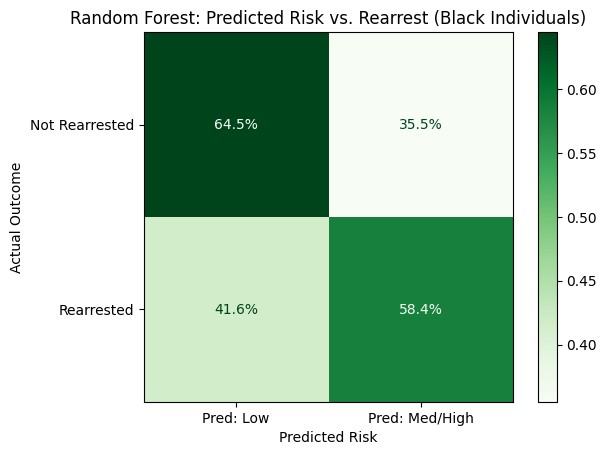

PPV (Precision): 0.6263


In [950]:
X_test_black_with_illegal = X_test_all[
    (X_test_all['race_African-American'] == 1)
]

X_test_black = X_test_black_with_illegal[allowed_columns]
Y_pred_black = skog.predict(X_test_black)

Y_test_black = X_test_black_with_illegal["two_year_recid"]

cm_rates = confusion_matrix(Y_test_black, Y_pred_black, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rates, 
                              display_labels=['Low Risk (0)', 'Med/High Risk (1)'])

disp.plot(cmap='Greens', values_format='.1%')


# Customize axis labels
disp.ax_.set_xlabel("Predicted Risk")
disp.ax_.set_ylabel("Actual Outcome")

# Customize tick labels separately
disp.ax_.set_xticklabels(['Pred: Low', 'Pred: Med/High'])
disp.ax_.set_yticklabels(['Not Rearrested', 'Rearrested'])

plt.title('Random Forest: Predicted Risk vs. Rearrest (Black Individuals)')
plt.show()

y_true = np.array(Y_test_black)
y_pred = np.array(Y_pred_black)

y_true_pos = (y_true == 1)
y_pred_pos = (y_pred == 1)

TP = np.sum(y_pred_pos & y_true_pos)
FP = np.sum(y_pred_pos & ~y_true_pos)
ppv = TP / (TP + FP) if (TP + FP) > 0 else 0.0

print(f"PPV (Precision): {ppv:.4f}")

### Feature importance

<BarContainer object of 4 artists>

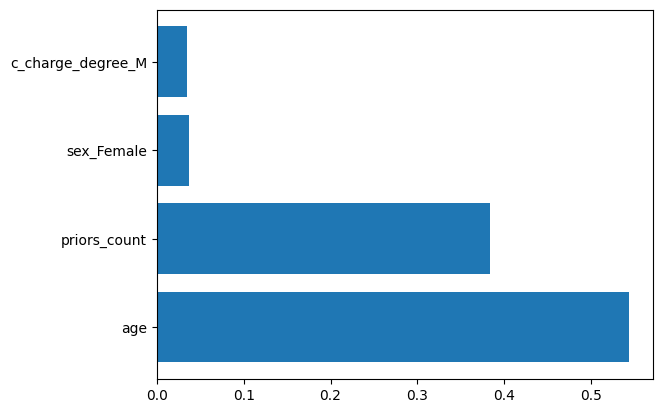

In [951]:
importance = skog.feature_importances_
plt.barh(X_train.columns, importance)